## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor,plot_importance
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import warnings
import random
import seaborn as sns

warnings.filterwarnings("ignore")

## Data Loading


In [2]:
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

print(f"Train Shape: {sales.shape} | Test Shape: {test.shape} | Promos Shape: {promotions.shape}")

Train Shape: (3833, 3) | Test Shape: (548, 3) | Promos Shape: (50, 10)


## Data Boundaries


In [3]:
print("--- DATE BOUNDARIES ---")
print(f"Train Period: {sales['Date'].min().date()} to {sales['Date'].max().date()}")
print(f"Test Period : {test['Date'].min().date()} to {test['Date'].max().date()}")

print("\n--- BASELINE REVENUE STATS ---")
print(sales[["Revenue", "COGS"]].describe().round(2))

--- DATE BOUNDARIES ---
Train Period: 2012-07-04 to 2022-12-31
Test Period : 2023-01-01 to 2024-07-01

--- BASELINE REVENUE STATS ---
           Revenue         COGS
count      3833.00      3833.00
mean    4286584.03   3695134.49
std     2624840.20   2219788.77
min      279813.94    236576.31
25%     2471088.82   2150580.23
50%     3647303.90   3161112.99
75%     5350877.20   4637293.92
max    20905271.35  16535857.67


## Feature Engineering


In [4]:
# 1. Đọc dữ liệu và chuẩn hóa kiểu datetime
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

# Lấy ID lớn nhất hiện tại (PROMO-0050 -> số 50)
max_id = int(promotions['promo_id'].str.extract(r'(\d+)')[0].max())

# 2. Rút trích Template
# Năm 2021 đại diện cho form năm lẻ (có 6 event)
template_2021 = promotions[promotions['start_date'].dt.year == 2021].copy()
# Năm 2022 đại diện cho form năm chẵn (có 4 event)
template_2022 = promotions[promotions['start_date'].dt.year == 2022].copy()

# 3. Hàm tạo Khuyến mãi tương lai
def generate_future_promos(template_df, target_year, ref_year, current_max_id):
    new_promos = template_df.copy()
    year_diff = target_year - ref_year
    
    # BƠM NHIỄU: Cộng/trừ ngẫu nhiên 1 đến 5 ngày để phá vỡ sự hoàn hảo
    noise_days = random.randint(0, 0) 
    
    new_promos['start_date'] = new_promos['start_date'] + pd.DateOffset(years=year_diff, days=noise_days)
    new_promos['end_date'] = new_promos['end_date'] + pd.DateOffset(years=year_diff, days=noise_days)
    # Cập nhật chuỗi ký tự tên (VD: "Spring Sale 2021" -> "Spring Sale 2023")
    new_promos['promo_name'] = new_promos['promo_name'].str.replace(str(ref_year), str(target_year))
    
    # Sinh tự động promo_id nối tiếp nhau
    new_ids = []
    for _ in range(len(new_promos)):
        current_max_id += 1
        new_ids.append(f"PROMO-{current_max_id:04d}")
    new_promos['promo_id'] = new_ids
    
    return new_promos, current_max_id

# 4. Thực thi sinh dữ liệu
promo_2023, max_id = generate_future_promos(template_2021, target_year=2023, ref_year=2021, current_max_id=max_id)
promo_2024, max_id = generate_future_promos(template_2022, target_year=2024, ref_year=2022, current_max_id=max_id)

# 5. Ghép nối bảng Khuyến mãi hoàn chỉnh
future_promos = pd.concat([promo_2023, promo_2024], ignore_index=True)
promotions = pd.concat([promotions, future_promos], ignore_index=True)

# In ra 10 dòng vừa được sinh ra để kiểm tra
print("--- CÁC CHIẾN DỊCH KHUYẾN MÃI ĐƯỢC TẠO MỚI CHO 2023 & 2024 ---")
display(future_promos)

--- CÁC CHIẾN DỊCH KHUYẾN MÃI ĐƯỢC TẠO MỚI CHO 2023 & 2024 ---


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0051,Spring Sale 2023,percentage,12.0,2023-03-18,2023-04-17,NaN,online,1,0
1,PROMO-0052,Mid-Year Sale 2023,percentage,18.0,2023-06-23,2023-07-22,NaN,social_media,1,0
2,PROMO-0053,Fall Launch 2023,percentage,10.0,2023-08-30,2023-10-02,NaN,email,0,0
3,PROMO-0054,Year-End Sale 2023,percentage,20.0,2023-11-18,2024-01-02,NaN,all_channels,1,0
4,PROMO-0055,Urban Blowout 2023,fixed,50.0,2023-07-30,2023-09-02,Streetwear,online,0,200000
5,PROMO-0056,Rural Special 2023,percentage,15.0,2023-01-30,2023-03-01,Outdoor,in_store,0,0
6,PROMO-0057,Spring Sale 2024,percentage,12.0,2024-03-18,2024-04-17,NaN,all_channels,1,0
7,PROMO-0058,Mid-Year Sale 2024,percentage,18.0,2024-06-23,2024-07-22,NaN,online,0,0
8,PROMO-0059,Fall Launch 2024,percentage,10.0,2024-08-31,2024-10-01,NaN,all_channels,0,0
9,PROMO-0060,Year-End Sale 2024,percentage,20.0,2024-11-18,2024-12-31,NaN,all_channels,0,50000


In [5]:
# =========================================================================
# 1. KHỞI TẠO & CALENDAR FEATURES
# =========================================================================
# =========================================================================
# 1. KHỞI TẠO, CALENDAR FEATURES & MÙA VỤ FOURIER
# =========================================================================
train = sales.copy()
train["is_test"] = 0
test_df_copy = test[["Date"]].copy() 
test_df_copy["is_test"] = 1
df = pd.concat([train, test_df_copy], ignore_index=True)

df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["day_of_year"] = df["Date"].dt.dayofyear
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year

# Lịch cơ bản
df["is_weekend"] = np.where(df["day_of_week"] >= 5, 1, 0)
df["is_payday_window"] = np.where((df["day_of_month"] >= 28) | (df["day_of_month"] <= 4), 1, 0)
df["is_double_day"] = np.where(df["month"] == df["day_of_month"], 1, 0)
df["days_since_start"] = (df["Date"] - df["Date"].min()).dt.days
df['quarter']    = df['Date'].dt.quarter

# ---> VŨ KHÍ MỚI 1: FOURIER TERMS (MÔ HÌNH HÓA MÙA VỤ LIÊN TỤC) <---
# Bậc 1: Chu kỳ 1 năm (Bắt nhịp Xuân/Hạ/Thu/Đông)
df['sin_365'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['cos_365'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

# Bậc 2: Chu kỳ nửa năm (Bắt các nhịp thời trang ngắn hạn hơn)
df['sin_182'] = np.sin(4 * np.pi * df['day_of_year'] / 365.25)
df['cos_182'] = np.cos(4 * np.pi * df['day_of_year'] / 365.25)
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12.0)


# =========================================================================
# 1.5. TẾT ANCHORS & EXPONENTIAL DECAY (TRỌNG SỐ TÂM LÝ)
# =========================================================================
tet_dates = {
    2012: "2012-01-23", 2013: "2013-02-10", 2014: "2014-01-31", 2015: "2015-02-19",
    2016: "2016-02-08", 2017: "2017-01-28", 2018: "2018-02-16", 2019: "2019-02-05",
    2020: "2020-01-25", 2021: "2021-02-12", 2022: "2022-02-01", 2023: "2023-01-22",
    2024: "2024-02-10"
}
tet_map = pd.DataFrame(list(tet_dates.items()), columns=["year", "tet_date"])
tet_map["tet_date"] = pd.to_datetime(tet_map["tet_date"])
df = df.merge(tet_map, on="year", how="left")
df["days_to_tet"] = (df["tet_date"] - df["Date"]).dt.days

# Cờ truyền thống (Dùng để kiểm soát các ngày sau Tết)
df["is_tet_holiday"] = np.where((df["days_to_tet"] <= 0) & (df["days_to_tet"] >= -6), 1, 0)

# Khai báo hệ số lambda (Tốc độ tăng nhiệt). 0.15 nghĩa là bắt đầu nóng từ 20 ngày trước Tết.
decay_lambda = 0.15 

# Chỉ áp dụng hàm mũ cho những ngày TRƯỚC Tết (days_to_tet >= 0). Qua Tết thì áp lực này về 0.
df['tet_decay_weight'] = np.where(
    df['days_to_tet'] >= 0,
    np.exp(-decay_lambda * df['days_to_tet']),
    0
)

# Cờ Mùa Vụ 8/3 & 20/10
df['is_womens_day_season'] = np.where(
    ((df['month'] == 3) & (df['day_of_month'] >= 1) & (df['day_of_month'] <= 8)) |
    ((df['month'] == 10) & (df['day_of_month'] >= 13) & (df['day_of_month'] <= 20)), 
    1, 0
)
# =========================================================================
# 2. KHUYẾN MÃI (PROMOTIONS) - TÍCH HỢP TẤT CẢ BIẾN
# =========================================================================
promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0, "max_disc": 0.0})

# Khởi tạo đầy đủ các cột
daily_p['num_active_promos'] = 0
daily_p['is_percentage_promo'] = 0
daily_p['is_fixed_promo'] = 0
daily_p['active_stackable_promos_count'] = 0

for _, row in promotions.iterrows():
    mask = (daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"])
    
    daily_p.loc[mask, "is_promo"] = 1
    daily_p.loc[mask, "num_active_promos"] += 1 
    
    if row["promo_type"] == "percentage":
        daily_p.loc[mask, "is_percentage_promo"] = 1
        daily_p.loc[mask, "max_disc"] = np.maximum(daily_p.loc[mask, "max_disc"], row["discount_value"])
    elif row["promo_type"] == "fixed":
        daily_p.loc[mask, "is_fixed_promo"] = 1
        
    if row["stackable_flag"] == 1:
        daily_p.loc[mask, "active_stackable_promos_count"] += 1

# Days to Next Promo
promo_starts = pd.DataFrame({'promo_start_date': pd.to_datetime(promotions['start_date'].unique())}).sort_values('promo_start_date')
daily_p = pd.merge_asof(daily_p.sort_values('Date'), promo_starts.assign(Date=promo_starts['promo_start_date']), on='Date', direction='forward')
daily_p['days_to_next_promo'] = (daily_p['promo_start_date'] - daily_p['Date']).dt.days.fillna(999)
daily_p = daily_p.drop(columns=['promo_start_date'])

# FOMO & DIP
promo_ends = pd.DataFrame({'promo_end_date': pd.to_datetime(promotions['end_date'].unique())}).sort_values('promo_end_date')
daily_p = pd.merge_asof(daily_p, promo_ends.assign(Date=promo_ends['promo_end_date']), on='Date', direction='backward')
daily_p['days_since_last_promo'] = (daily_p['Date'] - daily_p['promo_end_date']).dt.days.fillna(999)
daily_p = daily_p.drop(columns=['promo_end_date'])

daily_p['days_to_promo_end'] = 999 
for _, row in promotions.iterrows():
    mask = (daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"])
    daily_p.loc[mask, 'days_to_promo_end'] = (row["end_date"] - daily_p.loc[mask, "Date"]).dt.days

daily_p['is_post_sale_dip'] = np.where((daily_p['days_since_last_promo'] > 0) & (daily_p['days_since_last_promo'] <= 3), 1, 0)
daily_p['is_fomo_days'] = np.where((daily_p['days_to_promo_end'] >= 0) & (daily_p['days_to_promo_end'] <= 2), 1, 0)

# GỘP VÀO DF CHÍNH (Xóa các cột trùng trước nếu có)
df = df.merge(daily_p, on="Date", how="left").fillna(0)

# Tương tác Promo
df['promo_x_month_3'] = df['is_promo'] * np.where(df['month'] == 3, 1, 0)
df['promo_x_month_12'] = df['is_promo'] * np.where(df['month'] == 12, 1, 0)
# =========================================================================
# 2.5. TÍN HIỆU PHỄU TỪ WEB TRAFFIC & INVENTORY (PERPETUAL BASELINE)
# Giải quyết triệt để "Bẫy chân trời dự báo" cho năm 2024
# =========================================================================

# ---------------------------------------------------------
# A. XỬ LÝ WEB TRAFFIC (Mức nền an toàn cho cả 2023 và 2024)
# ---------------------------------------------------------
web_traffic = pd.read_csv(DATA_DIR + "web_traffic.csv", parse_dates=["date"])
inventory = pd.read_csv(DATA_DIR + "inventory.csv", parse_dates=["snapshot_date"])

web_traffic['year'] = web_traffic['date'].dt.year
web_traffic['month'] = web_traffic['date'].dt.month
web_traffic['day_of_week'] = web_traffic['date'].dt.dayofweek

inventory['year'] = inventory['snapshot_date'].dt.year
inventory['month'] = inventory['snapshot_date'].dt.month
# =========================================================================
# 3. SAFE LAG FEATURES (BẢN ĐẦY ĐỦ CHO TẬP SUBMISSION)
# =========================================================================
def create_safe_lag_features_full(data_frame):
    df_copy = data_frame.copy()
    global_avg = df_copy[df_copy['is_test'] == 0]['Revenue'].mean()
    
    historical_rev = df_copy[df_copy['is_test'] == 0].groupby(
        ['year', 'month', 'day_of_week']
    )['Revenue'].mean().reset_index()
    hist_traffic = web_traffic.groupby(['year', 'month', 'day_of_week'])['sessions'].mean().reset_index()
    
    # A3. Tồn kho quá khứ (Theo tháng)
    hist_inv = inventory.groupby(['year', 'month'])['stockout_flag'].mean().reset_index()
    # Lag 1 năm
    hist_1yr = historical_rev.copy()
    hist_1yr['target_year'] = hist_1yr['year'] + 1 
    hist_1yr = hist_1yr.drop(columns=['year']).rename(columns={'target_year': 'year', 'Revenue': 'lag_1yr_avg_rev'})
    
    # Lag 2 năm
    hist_2yr = historical_rev.copy()
    hist_2yr['target_year'] = hist_2yr['year'] + 2 
    hist_2yr = hist_2yr.drop(columns=['year']).rename(columns={'target_year': 'year', 'Revenue': 'lag_2yr_avg_rev'})

    # LAG Traffic
    lag1_traffic = hist_traffic.copy()
    lag1_traffic['year'] = lag1_traffic['year'] + 1
    lag1_traffic.rename(columns={'sessions': 'lag_1yr_avg_sessions'}, inplace=True)
    
    lag2_traffic = hist_traffic.copy()
    lag2_traffic['year'] = lag2_traffic['year'] + 2
    lag2_traffic.rename(columns={'sessions': 'lag_2yr_avg_sessions'}, inplace=True)
    
    # 3. Lag Inventory (Stockout)
    lag1_inv = hist_inv.copy()
    lag1_inv['year'] = lag1_inv['year'] + 1
    lag1_inv.rename(columns={'stockout_flag': 'lag_1yr_stockout_rate'}, inplace=True)
    
    lag2_inv = hist_inv.copy()
    lag2_inv['year'] = lag2_inv['year'] + 2
    lag2_inv.rename(columns={'stockout_flag': 'lag_2yr_stockout_rate'}, inplace=True)

    
    # Merge vào df
    df_copy = df_copy.merge(hist_1yr, on=['year', 'month', 'day_of_week'], how='left')
    df_copy = df_copy.merge(hist_2yr, on=['year', 'month', 'day_of_week'], how='left')

    # Merge Traffic
    df_copy = df_copy.merge(lag1_traffic, on=['year', 'month', 'day_of_week'], how='left')
    df_copy = df_copy.merge(lag2_traffic, on=['year', 'month', 'day_of_week'], how='left')
    
    # Merge Inventory
    df_copy = df_copy.merge(lag1_inv, on=['year', 'month'], how='left')
    df_copy = df_copy.merge(lag2_inv, on=['year', 'month'], how='left')

    base_rev = historical_rev[historical_rev['year'] >= 2021].groupby(['month', 'day_of_week'])['Revenue'].mean().reset_index(name='base_rev')
    base_traffic = hist_traffic[hist_traffic['year'] >= 2021].groupby(['month', 'day_of_week'])['sessions'].mean().reset_index(name='base_traffic')
    base_inv = hist_inv[hist_inv['year'] >= 2021].groupby(['month'])['stockout_flag'].mean().reset_index(name='base_inv')
    
    df_copy = df_copy.merge(base_rev, on=['month', 'day_of_week'], how='left')
    df_copy = df_copy.merge(base_traffic, on=['month', 'day_of_week'], how='left')
    df_copy = df_copy.merge(base_inv, on=['month'], how='left')
    
    df_copy['lag_1yr_avg_rev'] = df_copy['lag_1yr_avg_rev'].fillna(global_avg)
    df_copy['lag_2yr_avg_rev'] = df_copy['lag_2yr_avg_rev'].fillna(global_avg)

    
    df_copy['lag_1yr_avg_sessions'] = df_copy['lag_1yr_avg_sessions'].fillna(df_copy['base_traffic'])
    df_copy['lag_2yr_avg_sessions'] = df_copy['lag_2yr_avg_sessions'].fillna(df_copy['base_traffic'])
    
    df_copy['lag_1yr_stockout_rate'] = df_copy['lag_1yr_stockout_rate'].fillna(df_copy['base_inv'])
    df_copy['lag_2yr_stockout_rate'] = df_copy['lag_2yr_stockout_rate'].fillna(df_copy['base_inv'])
    
    df_copy.drop(columns=['base_rev', 'base_traffic', 'base_inv'], inplace=True)
    # Tính Log và các biến phái sinh
    df_copy['lag_1yr_avg_rev_log'] = np.log1p(df_copy['lag_1yr_avg_rev'])
    df_copy['lag_2yr_avg_rev_log'] = np.log1p(df_copy['lag_2yr_avg_rev'])
    
    df_copy['lag_avg_1_2_yr'] = (df_copy['lag_1yr_avg_rev_log'] + df_copy['lag_2yr_avg_rev_log']) / 2
    df_copy['lag_growth_diff'] = df_copy['lag_1yr_avg_rev_log'] - df_copy['lag_2yr_avg_rev_log']

    df_copy['lag_1yr_avg_sessions_log'] = np.log1p(df_copy['lag_1yr_avg_sessions'])
    df_copy['lag_2yr_avg_sessions_log'] = np.log1p(df_copy['lag_2yr_avg_sessions'])
    df_copy['lag_avg_1_2_yr_sessions_log'] = (df_copy['lag_1yr_avg_sessions_log'] + df_copy['lag_2yr_avg_sessions_log']) / 2
    
    # 3. Biến phái sinh Inventory (Tỷ lệ đứt hàng từ 0-1 nên không cần log, cộng trung bình luôn)
    df_copy['lag_avg_1_2_yr_stockout_rate'] = (df_copy['lag_1yr_stockout_rate'] + df_copy['lag_2yr_stockout_rate']) / 2
    return df_copy

df = create_safe_lag_features_full(df)


# =========================================================================
# 4. CHIA TẬP DATA & CAPPED TREND
# =========================================================================
df_cut = df[df['Date'] >= '2012-01-01'].copy()

final_train = df_cut[df_cut["is_test"] == 0].copy().reset_index(drop=True)
final_test = df_cut[df_cut["is_test"] == 1].copy().reset_index(drop=True)

final_train = df_cut[df_cut["is_test"] == 0].copy()
final_test = df_cut[df_cut["is_test"] == 1].copy()

max_train_days = final_train['days_since_start'].max()
final_train['capped_days'] = final_train['days_since_start']
final_test['capped_days'] = final_test['days_since_start'].clip(upper=max_train_days)

In [6]:
final_train.columns

Index(['Date', 'Revenue', 'COGS', 'is_test', 'day_of_week', 'day_of_month',
       'day_of_year', 'month', 'year', 'is_weekend', 'is_payday_window',
       'is_double_day', 'days_since_start', 'quarter', 'sin_365', 'cos_365',
       'sin_182', 'cos_182', 'month_sin', 'month_cos', 'tet_date',
       'days_to_tet', 'is_tet_holiday', 'tet_decay_weight',
       'is_womens_day_season', 'is_promo', 'max_disc', 'num_active_promos',
       'is_percentage_promo', 'is_fixed_promo',
       'active_stackable_promos_count', 'days_to_next_promo',
       'days_since_last_promo', 'days_to_promo_end', 'is_post_sale_dip',
       'is_fomo_days', 'promo_x_month_3', 'promo_x_month_12',
       'lag_1yr_avg_rev', 'lag_2yr_avg_rev', 'lag_1yr_avg_sessions',
       'lag_2yr_avg_sessions', 'lag_1yr_stockout_rate',
       'lag_2yr_stockout_rate', 'lag_1yr_avg_rev_log', 'lag_2yr_avg_rev_log',
       'lag_avg_1_2_yr', 'lag_growth_diff', 'lag_1yr_avg_sessions_log',
       'lag_2yr_avg_sessions_log', 'lag_avg_1_2_yr_

## Target Transformation

In [7]:
# Split back to train/test
train_df = df[df["is_test"] == 0].copy()
test_df = df[df["is_test"] == 1].copy()

# LOG TRANSFORMATION: Squashes variance and allows exponential growth
final_train["target_rev"] = np.log1p(final_train["Revenue"])
final_train["target_cogs"] = np.log1p(final_train["COGS"])

features = [
   "day_of_week", "day_of_month", "day_of_year", "month", "is_weekend",
    "is_payday_window", "is_double_day", "capped_days", "quarter", "year",
    #Fourier
    "sin_365", "cos_365", "sin_182", "cos_182","month_sin", "month_cos",
    # 3. LỄ TẾT VÀ HÀNH VI TÂM LÝ
    "days_to_tet", "tet_decay_weight",
    "is_tet_holiday", "is_womens_day_season",
    # # # PROMOTIONS
    "is_promo", "max_disc", "days_to_next_promo",
    "is_fixed_promo",
    "promo_x_month_3", "promo_x_month_12",
    "is_post_sale_dip", "is_fomo_days",
    # # ---> TÍCH HỢP SAFE LAGS VÀO ĐÂY <---
    # "lag_1yr_avg_rev_log", "lag_2yr_avg_rev_log",
    # "lag_avg_1_2_yr",
    # # TÍN HIỆU PHỄU TỪ NĂM NGOÁI
    # 'lag_1yr_stockout_rate','lag_2yr_stockout_rate','lag_avg_1_2_yr_stockout_rate',
    #'lag_1yr_avg_sessions_log','lag_2yr_avg_sessions_log', 'lag_avg_1_2_yr_sessions_log',
]
# features = [
#     'year', 'month', 'day_of_month', 'day_of_week', 'is_weekend',
#     'day_of_year', 'quarter', 'is_payday_window', 'month_sin', 'month_cos'
# ]

X_train = final_train[features]
X_test = final_test[features]

In [8]:
X_train.columns

Index(['day_of_week', 'day_of_month', 'day_of_year', 'month', 'is_weekend',
       'is_payday_window', 'is_double_day', 'capped_days', 'quarter', 'year',
       'sin_365', 'cos_365', 'sin_182', 'cos_182', 'month_sin', 'month_cos',
       'days_to_tet', 'tet_decay_weight', 'is_tet_holiday',
       'is_womens_day_season', 'is_promo', 'max_disc', 'days_to_next_promo',
       'is_fixed_promo', 'promo_x_month_3', 'promo_x_month_12',
       'is_post_sale_dip', 'is_fomo_days'],
      dtype='object')

In [9]:
X_test.columns

Index(['day_of_week', 'day_of_month', 'day_of_year', 'month', 'is_weekend',
       'is_payday_window', 'is_double_day', 'capped_days', 'quarter', 'year',
       'sin_365', 'cos_365', 'sin_182', 'cos_182', 'month_sin', 'month_cos',
       'days_to_tet', 'tet_decay_weight', 'is_tet_holiday',
       'is_womens_day_season', 'is_promo', 'max_disc', 'days_to_next_promo',
       'is_fixed_promo', 'promo_x_month_3', 'promo_x_month_12',
       'is_post_sale_dip', 'is_fomo_days'],
      dtype='object')

In [10]:
# # Xem cột này có bao nhiêu giá trị khác nhau
# print(X_train['days_to_next_promo'].value_counts().head(10))

## Model Training


In [11]:
# # Tuned parameters from optuna search
# best_params = {
#     "n_estimators": 1500,
#     "learning_rate": 0.03,
#     "max_depth": 7,
#     "num_leaves": 31,
#     "subsample": 0.8,
#     "colsample_bytree": 0.8,
#     "random_state": 42,
#     "importance_type": 'gain',
#     "verbosity": -1,
# }

# print("Training Log-Revenue Model...")
# tscv = TimeSeriesSplit(n_splits=5)
# model_rev = lgb.LGBMRegressor(**best_params)
# model_cogs = lgb.LGBMRegressor(**best_params)

# model_rev.fit(X_train, final_train["target_rev"])
# model_cogs.fit(X_train, final_train["target_cogs"])

# # Predict and Inverse Log
# final_test["Revenue"] = np.expm1(model_rev.predict(X_test))
# final_test["COGS"] = np.expm1(model_cogs.predict(X_test))

In [10]:
def calculate_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def print_metrics_table(metrics_per_fold: dict, target_name: str):
    """
    In bảng kết quả từng fold + dòng tổng kết MEAN / STD.
    metrics_per_fold = {
        'WAPE': [...], 'MAE': [...], 'RMSE': [...], 'R2': [...]
    }
    """
    header = f"{'Fold':>6} | {'WAPE':>8} | {'MAE':>14} | {'RMSE':>14} | {'R²':>8}"
    sep    = "-" * len(header)

    print(f"\n{'='*len(header)}")
    print(f"  KẾT QUẢ CV – {target_name.upper()}")
    print(f"{'='*len(header)}")
    print(header)
    print(sep)

    n_folds = len(metrics_per_fold['WAPE'])
    for i in range(n_folds):
        print(
            f"{i+1:>6} | "
            f"{metrics_per_fold['WAPE'][i]:>7.2%} | "
            f"{metrics_per_fold['MAE'][i]:>14,.0f} | "
            f"{metrics_per_fold['RMSE'][i]:>14,.0f} | "
            f"{metrics_per_fold['R2'][i]:>8.4f}"
        )

    print(sep)

    # MEAN
    means = {k: np.mean(v) for k, v in metrics_per_fold.items()}
    stds  = {k: np.std(v)  for k, v in metrics_per_fold.items()}

    print(
        f"{'MEAN':>6} | "
        f"{means['WAPE']:>7.2%} | "
        f"{means['MAE']:>14,.0f} | "
        f"{means['RMSE']:>14,.0f} | "
        f"{means['R2']:>8.4f}"
    )
    # STD
    print(
        f"{'STD':>6} | "
        f"{stds['WAPE']:>7.2%} | "
        f"{stds['MAE']:>14,.0f} | "
        f"{stds['RMSE']:>14,.0f} | "
        f"{stds['R2']:>8.4f}"
    )
    print(f"{'='*len(header)}\n")

In [11]:
# Tuned parameters from optuna search
best_params = {
    "n_estimators": 1500,
    "learning_rate": 0.03,
    "max_depth": 7,
    "num_leaves": 101,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "importance_type": 'gain',
    "verbosity": -1,
}
# xgb_params = {
#     "n_estimators": 1500,
#     "learning_rate": 0.03,
#     "max_depth": 6,                 # Ép xuống 5 để tương đương với ~32 lá. KHÔNG dùng 7.
#     "subsample": 0.8,
#     "colsample_bytree": 0.8,
#     "random_state": 42,
#     "importance_type": 'gain',
    
#     # --- Các thông số nên bổ sung thêm cho XGBoost ---
#     "tree_method": "hist",          # Bắt buộc để chạy nhanh như LightGBM trên dữ liệu lớn
#     "min_child_weight": 1,          # (Tương đương min_child_samples của LGBM, default là 1)
#     "n_jobs": -1,
#     "early_stopping_rounds": 100,
# }
print("Training Log-Revenue Model...")
tscv = TimeSeriesSplit(
    n_splits=5)
def train_lgb_target(target_name):
    models  = []
    metrics = {'WAPE': [], 'MAE': [], 'RMSE': [], 'R2': []}

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr = X_train.loc[train_idx, features]
        X_va = X_train.loc[val_idx,   features]

        y_tr       = final_train.loc[train_idx, target_name]
        y_va_log   = final_train.loc[val_idx,   target_name]
        y_va_actual = np.expm1(final_train.loc[val_idx, target_name])

        model = lgb.LGBMRegressor(**best_params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va_log)],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
        )


        # Inverse transform
        preds_actual = np.expm1(model.predict(X_va))

        # Ghi metrics từng fold
        metrics['WAPE'].append(calculate_wape(y_va_actual, preds_actual))
        metrics['MAE'].append(mean_absolute_error(y_va_actual, preds_actual))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(y_va_actual, preds_actual)))
        metrics['R2'].append(r2_score(y_va_actual, preds_actual))

        models.append(model)

    # In bảng sau khi chạy xong tất cả fold
    print_metrics_table(metrics, target_name)
    return models

models_rev  = train_lgb_target('target_rev')
models_cogs = train_lgb_target('target_cogs')


test_preds_rev = np.mean(
    [np.expm1(m.predict(X_test[features])) for m in models_rev], axis=0
)
test_preds_cogs = np.mean(
    [np.expm1(m.predict(X_test[features])) for m in models_cogs], axis=0
)

# Ràng buộc tài chính
test_preds_rev  = np.clip(test_preds_rev,  0, None)
test_preds_cogs = np.clip(test_preds_cogs, 0, None)
test_preds_cogs = np.minimum(test_preds_cogs, test_preds_rev)
final_test["Revenue"] = test_preds_rev
final_test["COGS"] = test_preds_cogs

Training Log-Revenue Model...

  KẾT QUẢ CV – TARGET_REV
  Fold |     WAPE |            MAE |           RMSE |       R²
--------------------------------------------------------------
     1 |  21.50% |      1,126,029 |      1,570,330 |   0.6590
     2 |  18.21% |      1,055,554 |      1,510,941 |   0.7695
     3 |  29.90% |      1,343,042 |      1,854,205 |   0.5355
     4 |  30.81% |        830,992 |      1,091,907 |   0.4957
     5 |  17.95% |        554,323 |        755,181 |   0.7859
--------------------------------------------------------------
  MEAN |  23.67% |        981,988 |      1,356,513 |   0.6491
   STD |   5.60% |        269,153 |        387,009 |   0.1181


  KẾT QUẢ CV – TARGET_COGS
  Fold |     WAPE |            MAE |           RMSE |       R²
--------------------------------------------------------------
     1 |  19.21% |        869,349 |      1,222,072 |   0.7006
     2 |  17.92% |        898,525 |      1,285,428 |   0.7662
     3 |  30.02% |      1,128,071 |      

## Feature Importance


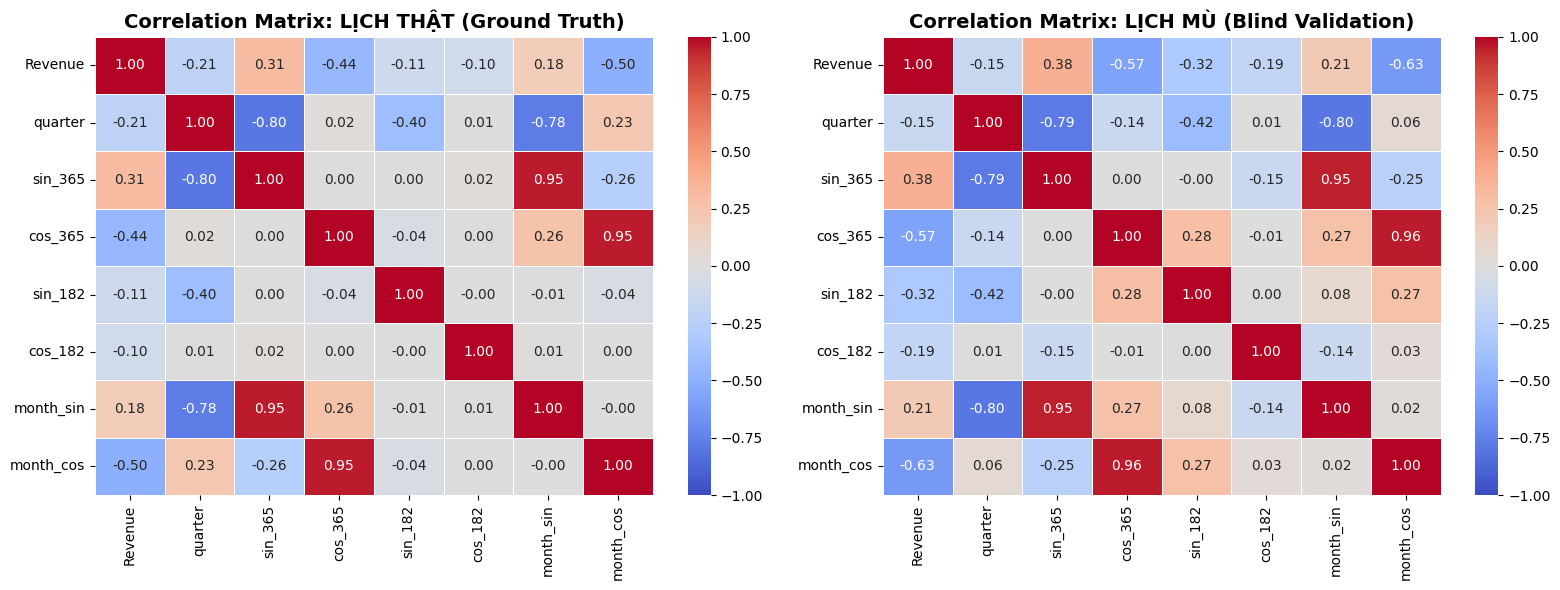

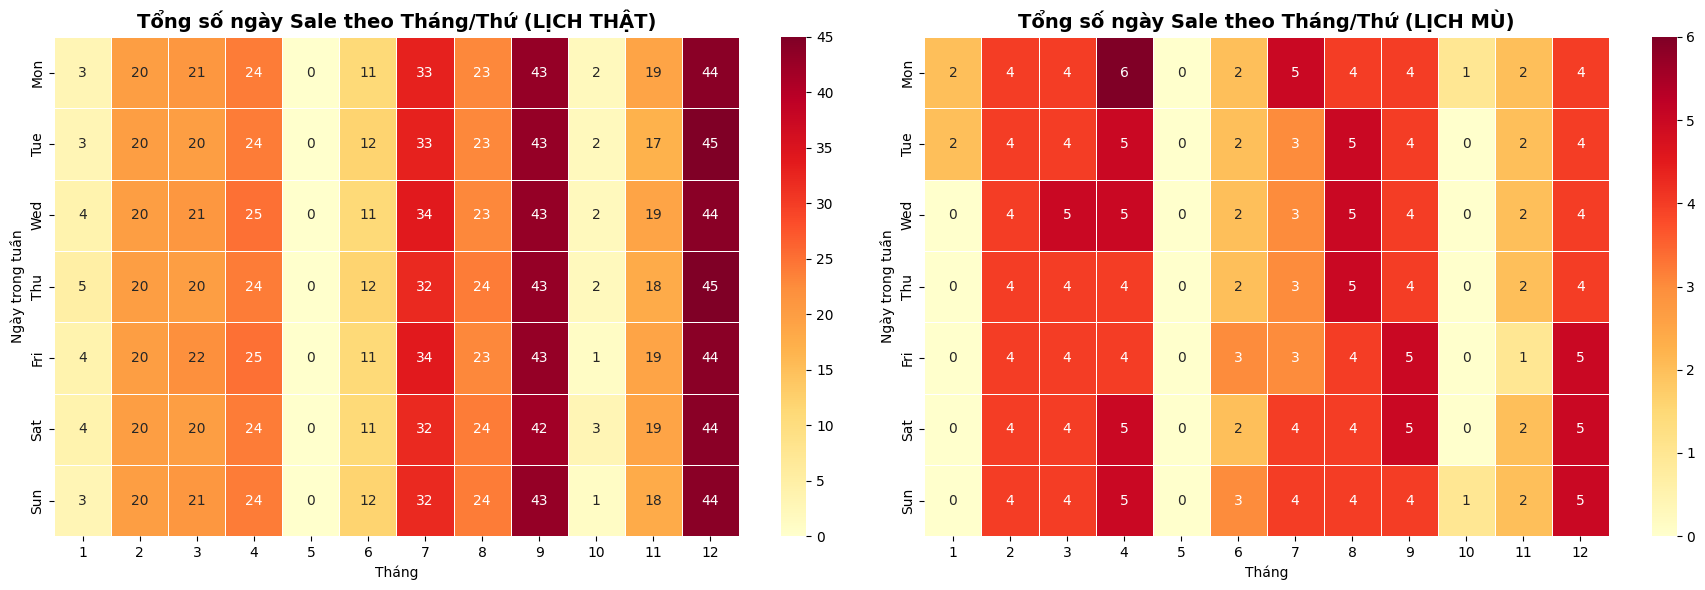

In [12]:
val_start_date = '2012-01-01'

viz_real = final_train[(final_train['Date'] >= val_start_date)].copy()
viz_blind = final_test[(final_test['Date'] >= val_start_date) ].copy()

# Chọn các biến cốt lõi để so sánh
cols_to_compare = [
    "Revenue",
   # "day_of_week", "day_of_month", "day_of_year", "month", "is_weekend",
   #  "is_payday_window", "is_double_day", "capped_days",
    "quarter",
    #Fourier
    "sin_365", "cos_365", "sin_182", "cos_182","month_sin", "month_cos",
    # 3. LỄ TẾT VÀ HÀNH VI TÂM LÝ
    # "days_to_tet", "tet_decay_weight", # Thay thế is_pre_tet_rush bằng hàm mũ
    # "is_tet_holiday", "is_womens_day_season",
    # # # PROMOTIONS
    # "is_promo", "max_disc", "days_to_next_promo",
    # "is_fixed_promo",
    # "promo_x_month_3", "promo_x_month_12",
    # "is_post_sale_dip", "is_fomo_days",
    # # ---> TÍCH HỢP SAFE LAGS VÀO ĐÂY <---
    # "lag_1yr_avg_rev_log", "lag_2yr_avg_rev_log",
    #  "lag_avg_1_2_yr",
    # # TÍN HIỆU PHỄU TỪ NĂM NGOÁI
    # "seasonal_base_sessions_log", 
    # "seasonal_base_stockout_rate"
]

plt.figure(figsize=(16, 6))

# # Subplot 1: Tập Thật
plt.subplot(1, 2, 1)
corr_real = viz_real[cols_to_compare].corr()
sns.heatmap(corr_real, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix: LỊCH THẬT (Ground Truth)", fontsize=14, fontweight='bold')

# Subplot 2: Tập Mù
plt.subplot(1, 2, 2)
corr_blind = viz_blind[cols_to_compare].corr()
sns.heatmap(corr_blind, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix: LỊCH MÙ (Blind Validation)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



# Tạo ma trận [Tháng, Thứ] đếm tổng số ngày có Khuyến Mãi
pivot_real = viz_real.pivot_table(index='day_of_week', columns='month', values='is_promo', aggfunc='sum')
pivot_blind = viz_blind.pivot_table(index='day_of_week', columns='month', values='is_promo', aggfunc='sum')

# Thay số thành tên thứ cho dễ nhìn
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot_real.index = [day_names[i] for i in pivot_real.index]
pivot_blind.index = [day_names[i] for i in pivot_blind.index]

plt.figure(figsize=(18, 6))

# Subplot 1
plt.subplot(1, 2, 1)
sns.heatmap(pivot_real, cmap='YlOrRd', annot=True, fmt=".0f", linewidths=.5)
plt.title("Tổng số ngày Sale theo Tháng/Thứ (LỊCH THẬT)", fontsize=14, fontweight='bold')
plt.xlabel("Tháng")
plt.ylabel("Ngày trong tuần")

# Subplot 2
plt.subplot(1, 2, 2)
sns.heatmap(pivot_blind, cmap='YlOrRd', annot=True, fmt=".0f", linewidths=.5)
plt.title("Tổng số ngày Sale theo Tháng/Thứ (LỊCH MÙ)", fontsize=14, fontweight='bold')
plt.xlabel("Tháng")
plt.ylabel("Ngày trong tuần")

plt.tight_layout()
plt.show()

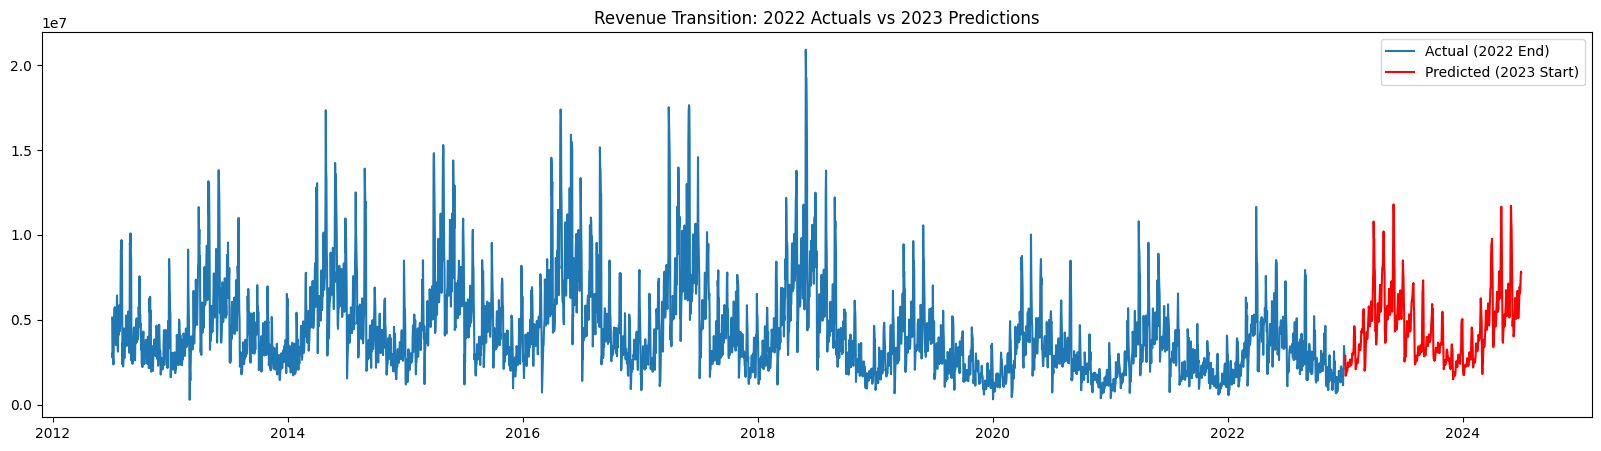

Đã lưu → shap_revenue_drivers.png


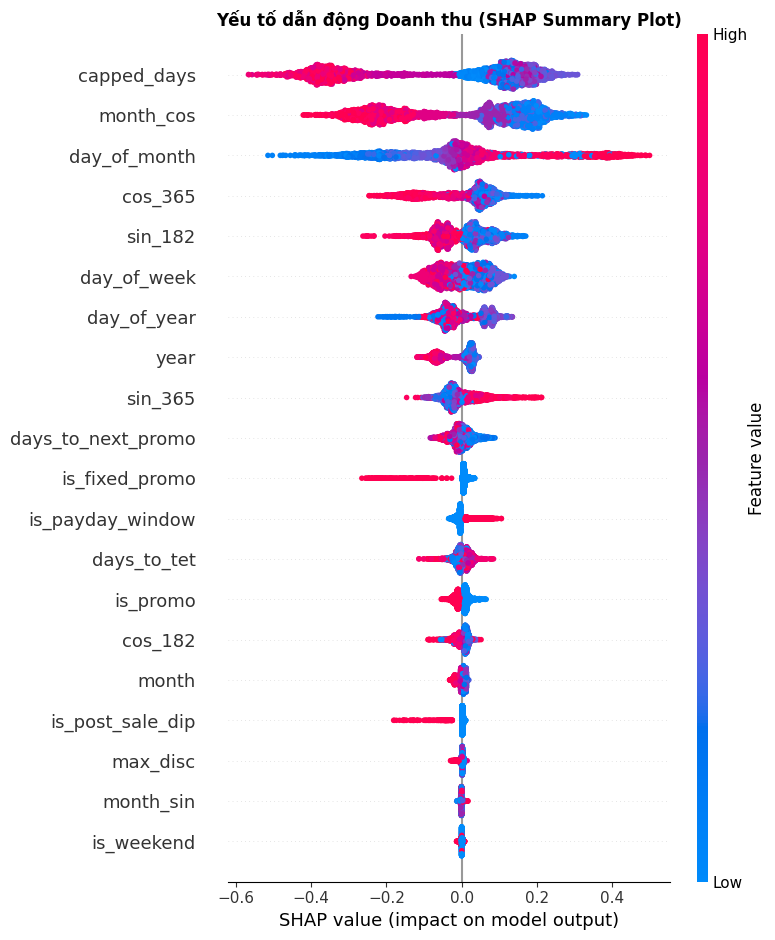

In [17]:
# Compare Training Tail with Prediction Head
plt.figure(figsize=(20, 5))
plt.plot(
    final_train["Date"].tail(10000),
    final_train["Revenue"].tail(10000), 
    label="Actual (2022 End)"
)
plt.plot(
    final_test["Date"].head(600),
    final_test["Revenue"].head(600),
    label="Predicted (2023 Start)",
    color="red",
)
plt.title("Revenue Transition: 2022 Actuals vs 2023 Predictions")
plt.legend()
plt.show()

# Feature Importance
explainer   = shap.TreeExplainer(models_rev[-1])
shap_values = explainer.shap_values(X_train[features])

plt.title("Yếu tố dẫn động Doanh thu (SHAP Summary Plot)", fontweight='bold')
shap.summary_plot(shap_values, X_train[features], show=False)
plt.tight_layout()
plt.savefig('shap_revenue_drivers.png', dpi=300, bbox_inches='tight')
print("Đã lưu → shap_revenue_drivers.png")

In [13]:
import pandas as pd
import plotly.graph_objects as go

# 1. Đảm bảo cột Date có định dạng datetime
final_train['Date'] = pd.to_datetime(final_train['Date'])
final_test['Date'] = pd.to_datetime(final_test['Date'])

# 2. Gom nhóm theo Tháng và tính Trung bình Doanh thu hằng ngày (Avg Daily Revenue per Month)
# Sử dụng 'M' (Month End) hoặc 'MS' (Month Start) để resample
train_monthly = final_train.set_index('Date')['Revenue'].resample('MS').mean().reset_index()
test_monthly = final_test.set_index('Date')['Revenue'].resample('MS').mean().reset_index()

# Tùy chọn: Chỉ lấy dữ liệu Train từ năm 2021 trở đi để biểu đồ tập trung vào đoạn chuyển giao
train_tail = train_monthly[train_monthly['Date'].dt.year >= 2011].copy()

# 3. Kỹ thuật nối liền mạch biểu đồ: 
# Thêm tháng cuối cùng của tập Train vào đầu tập Test để đường (line) không bị đứt đoạn
last_train_month = train_tail.iloc[[-1]]
test_connected = pd.concat([last_train_month, test_monthly], ignore_index=True)

# 4. Trực quan hóa bằng Plotly
fig = go.Figure()

# Thêm đường Doanh thu Thực tế (Train)
fig.add_trace(go.Scatter(
    x=train_tail['Date'], 
    y=train_tail['Revenue'],
    mode='lines+markers', 
    name='Thực tế (Train: 2021 - 2022)',
    line=dict(color='#1f77b4', width=2.5),
    marker=dict(size=6)
))

# Thêm đường Doanh thu Dự báo (Test)
fig.add_trace(go.Scatter(
    x=test_connected['Date'], 
    y=test_connected['Revenue'],
    mode='lines+markers', 
    name='Dự báo (Test: 2023 - 2024)',
    line=dict(color='#d62728', width=2.5, dash='dash'), # Nét đứt thể hiện dữ liệu dự báo
    marker=dict(size=6)
))

# 5. Tùy chỉnh Layout cho chuyên nghiệp
fig.update_layout(
    title='Phân tích Chuyển tiếp: Trung bình Doanh thu Ngày theo Tháng (Thực tế vs Dự báo)',
    xaxis_title='Thời Gian (Tháng)',
    yaxis_title='Trung bình Doanh Thu Thuần / Ngày (VND)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

# Đánh dấu ranh giới giữa Train và Test bằng một đường dọc
fig.add_vline(x=last_train_month['Date'].values[0], line_width=1.5, line_dash="dot", line_color="grey")
fig.add_annotation(
    x=last_train_month['Date'].values[0], 
    y=max(train_tail['Revenue'].max(), test_monthly['Revenue'].max()), 
    text="Bắt đầu dự báo (2023)", 
    showarrow=False, 
    xshift=65, 
    font=dict(color="grey", size=11)
)

fig.show()

## Export Submission


In [14]:
submission = final_test[["Date", "Revenue", "COGS"]].copy()
submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")
submission.to_csv("submission.csv", index=False)
print("Saved 'submission.csv'!")

Saved 'submission.csv'!


In [15]:
pd.read_csv("/kaggle/working/submission.csv")

,Date,Revenue,COGS
0,2023-01-01,2.952382e+06,2.191459e+06
1,2023-01-02,1.678303e+06,1.431067e+06
2,2023-01-03,1.751340e+06,1.452130e+06
3,2023-01-04,1.868892e+06,1.532198e+06
4,2023-01-05,1.893864e+06,1.559748e+06
...,...,...,...
543,2024-06-27,6.518088e+06,6.041740e+06
544,2024-06-28,6.688634e+06,6.061625e+06
545,2024-06-29,7.362584e+06,6.775713e+06
546,2024-06-30,7.911918e+06,7.600786e+06
